In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("adult.csv")

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.shape

(32561, 15)

In [ ]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=32561, step=1)

In [ ]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.describe(include="object")

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.replace("?",np.nan,inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
# EDA


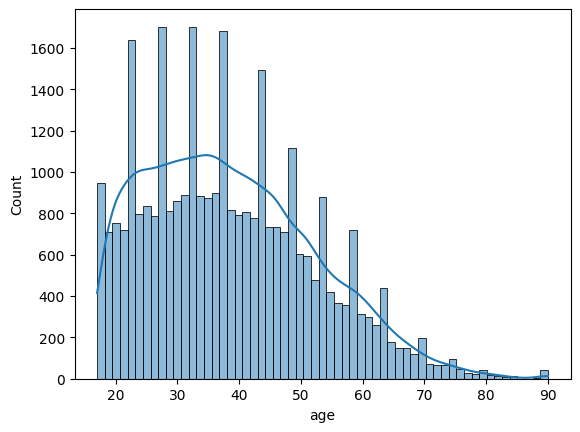

In [ ]:
# histogram

sns.histplot(df["age"],kde=True)
plt.show()

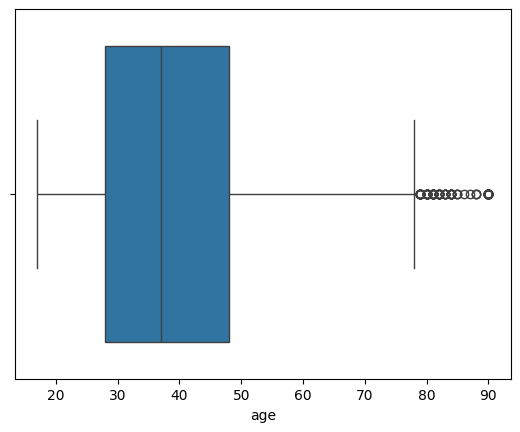

In [ ]:
# boxplot
sns.boxplot(x=df["age"])
plt.show()

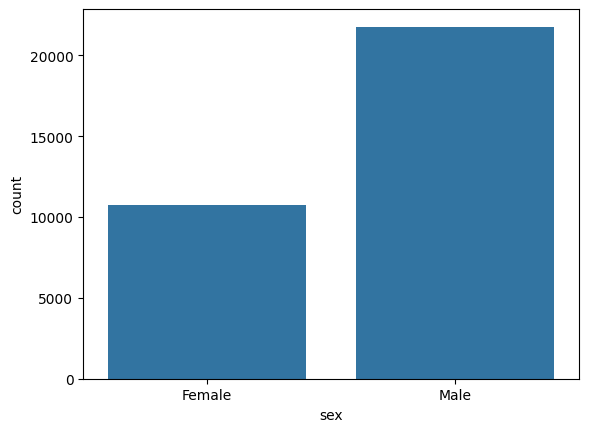

In [ ]:
# count plot
sns.countplot(x=df["sex"])
plt.show()

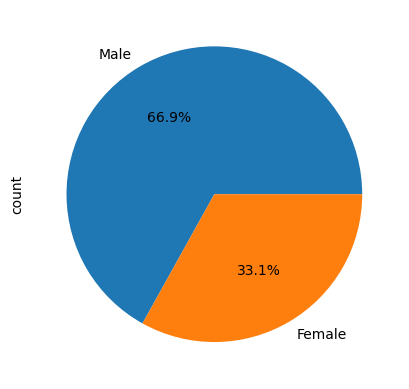

In [ ]:
# pie chart
df["sex"].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

In [ ]:
# frequency count
df["sex"].value_counts()

,count
sex,
Male,21775
Female,10762


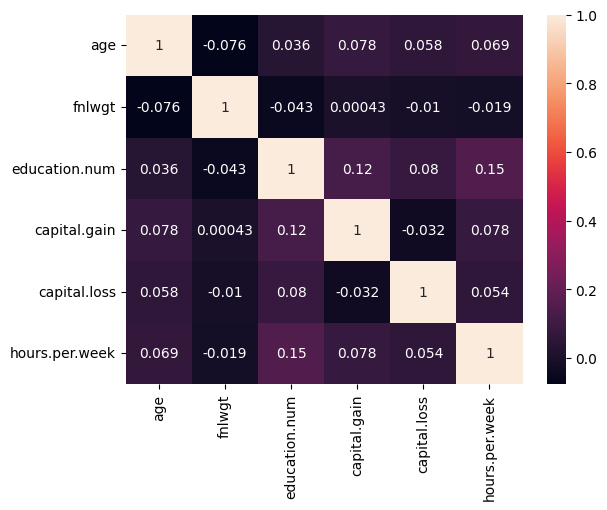

In [ ]:
# heatmap
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

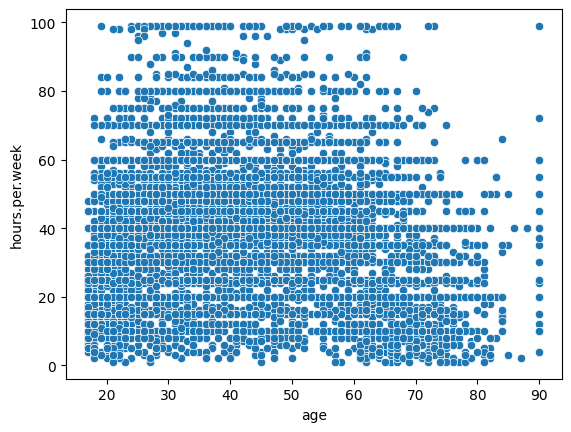

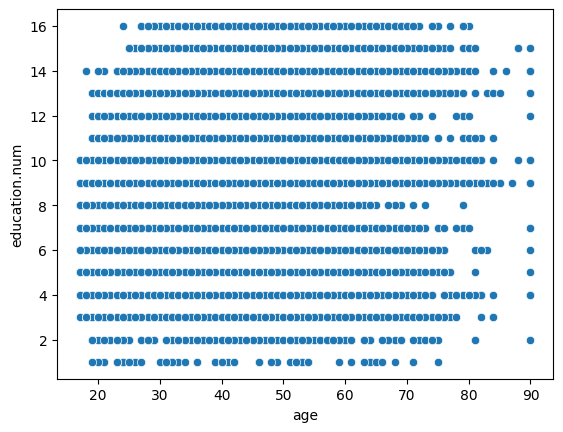

In [ ]:
# scatter plot
sns.scatterplot(data=df,x="age",y="hours.per.week")
plt.show()
sns.scatterplot(data=df,x="age",y="education.num")
plt.show()


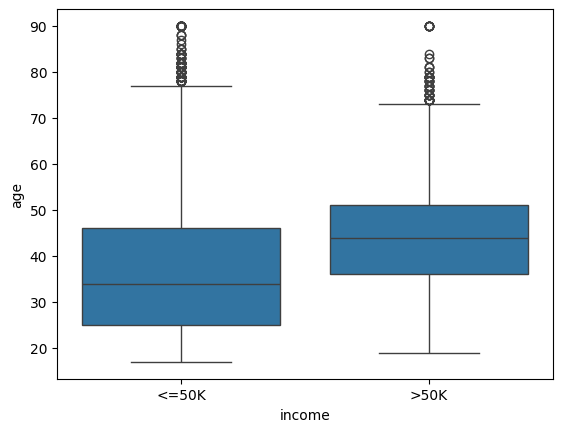

In [ ]:
sns.boxplot(data=df,x="income",y="age")
plt.show()

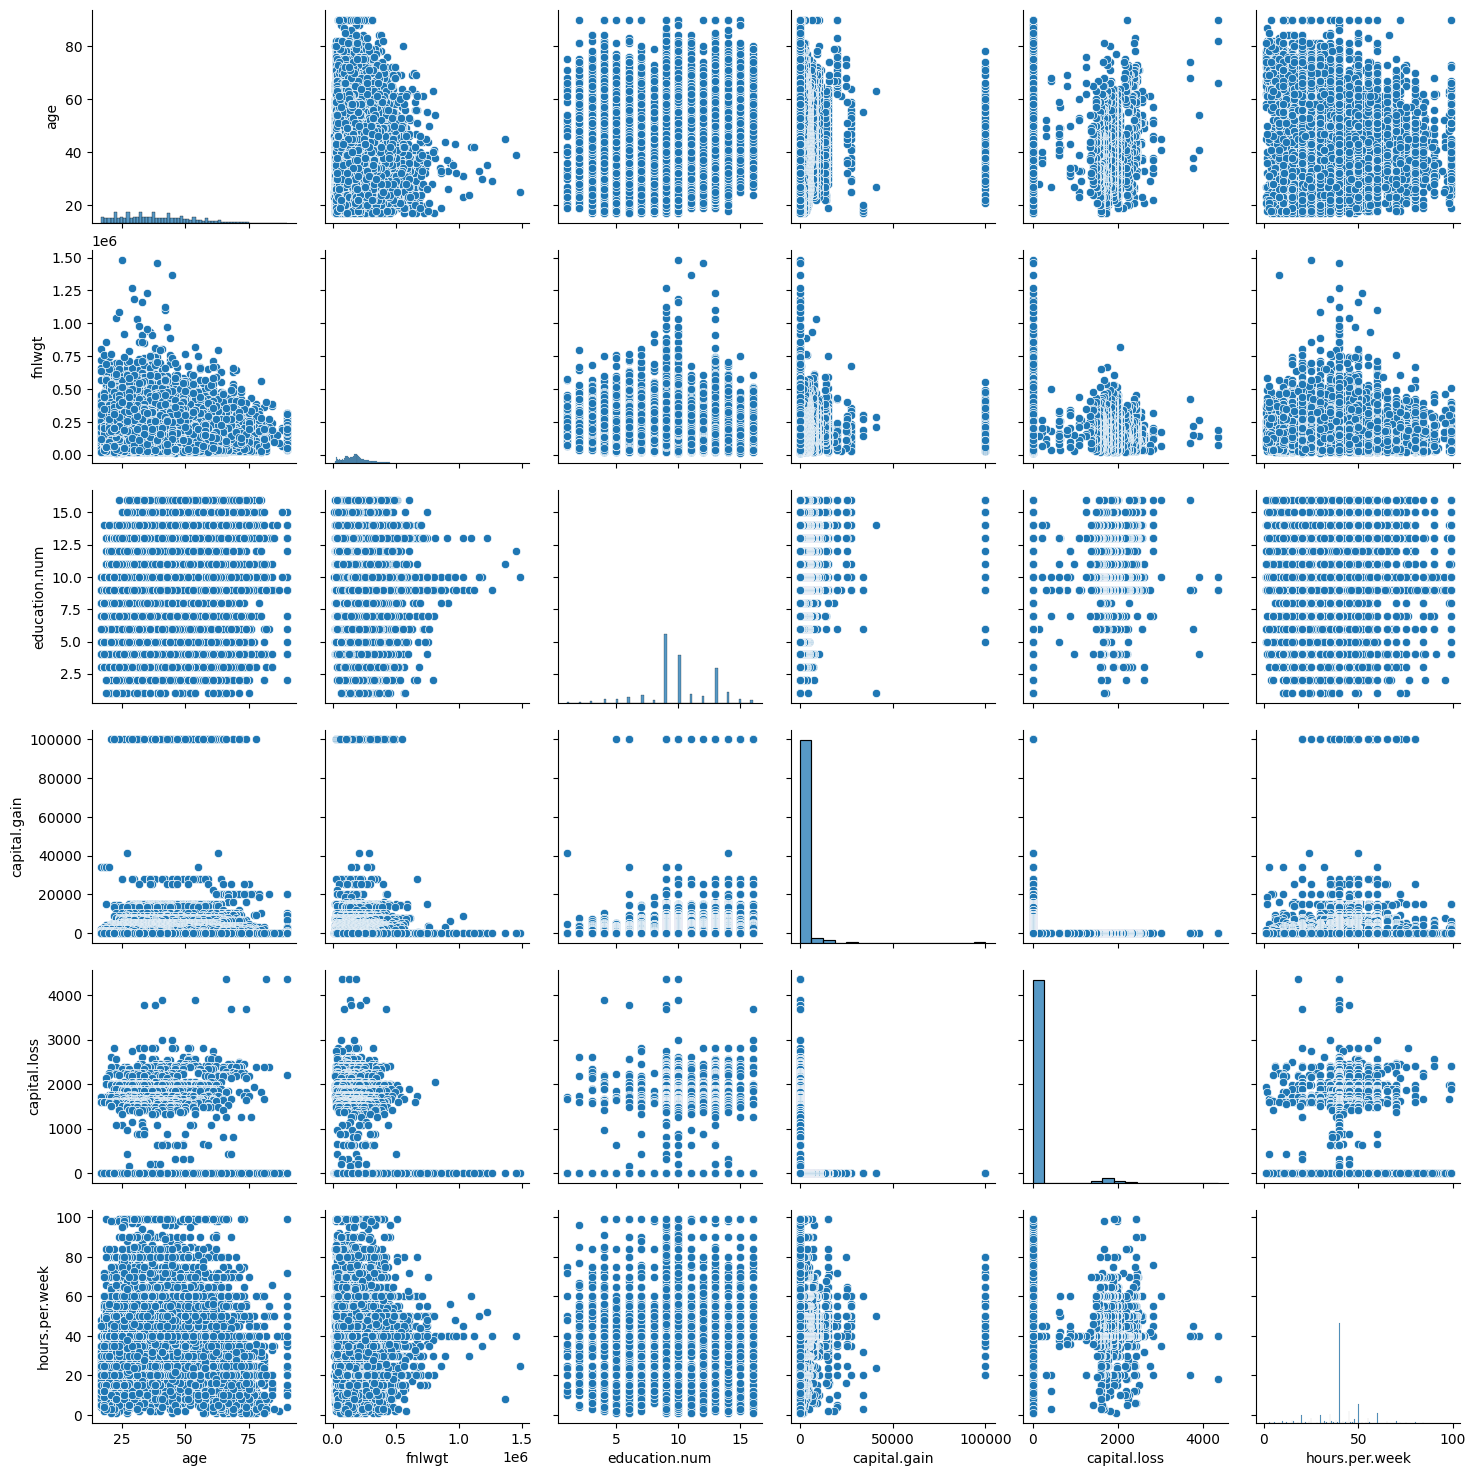

In [ ]:
sns.pairplot(df)

In [ ]:
# missing value

(df.isnull().sum() / len(df)) * 100

,0
age,0.000000
workclass,5.642807
fnlwgt,0.000000
education,0.000000
education.num,0.000000
marital.status,0.000000
occupation,5.664321
relationship,0.000000
race,0.000000
sex,0.000000


In [ ]:
df[['workclass', 'occupation', 'native.country']].dtypes

,0
workclass,object
occupation,object
native.country,object


In [ ]:
df["workclass"].value_counts()


,count
workclass,
Private,22673
Self-emp-not-inc,2540
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [ ]:
df["occupation"].value_counts()

,count
occupation,
Prof-specialty,4136
Craft-repair,4094
Exec-managerial,4065
Adm-clerical,3768
Sales,3650
Other-service,3291
Machine-op-inspct,2000
Transport-moving,1597
Handlers-cleaners,1369


In [ ]:
df["native.country"].value_counts()

,count
native.country,
United-States,29153
Mexico,639
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100
Cuba,95


In [ ]:
df["workclass"].mode()

,workclass
0,Private


In [ ]:
df["occupation"].mode()

,occupation
0,Prof-specialty


In [ ]:
df["native.country"].mode()

,native.country
0,United-States


In [ ]:
df["workclass"].fillna(df["workclass"].mode()[0], inplace=True)

df["occupation"].fillna(df["occupation"].mode()[0], inplace=True)

df["native.country"].fillna(df["native.country"].mode()[0], inplace=True)

/tmp/ipykernel_4650/376244352.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["workclass"].fillna(df["workclass"].mode()[0], inplace=True)
/tmp/ipykernel_4650/376244352.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
# outlier
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

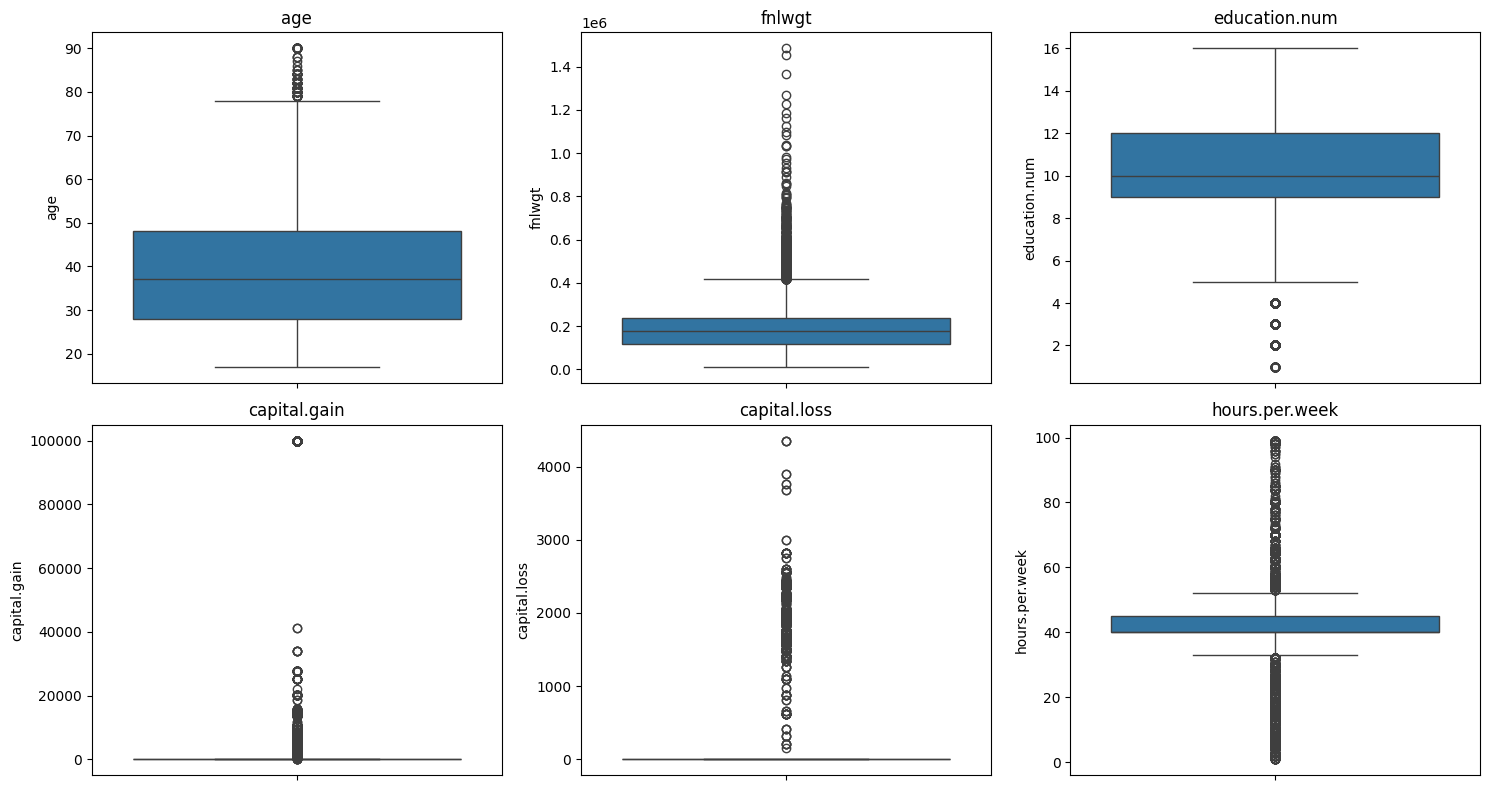

In [ ]:
plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
df[num_cols].skew()

,0
age,0.557663
fnlwgt,1.447703
education.num,-0.309500
capital.gain,11.949403
capital.loss,4.592702
hours.per.week,0.228759


In [ ]:
# IQR for age
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)

print("Q1 =", Q1)
print("Q3 =", Q3)
IQR = Q3 - Q1
print("IQR =", IQR)

Q1 = 28.0
Q3 = 48.0
IQR = 20.0


In [ ]:
lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

print("Lower Limit =", lower_limit)
print("Upper Limit =", upper_limit)

Lower Limit = -2.0
Upper Limit = 78.0


In [ ]:
df[(df["age"] < lower_limit) | (df["age"] > upper_limit)].shape

(142, 15)

In [ ]:
df.loc[df["age"] > upper_limit, ["age", "occupation", "income"]]

,age,occupation,income
0,90,Prof-specialty,<=50K
1,82,Exec-managerial,<=50K
118,83,Exec-managerial,>50K
128,81,Exec-managerial,>50K
199,90,Other-service,<=50K
...,...,...,...
31939,82,Farming-fishing,<=50K
32305,90,Adm-clerical,<=50K
32468,85,Exec-managerial,<=50K
32500,82,Prof-specialty,<=50K


In [ ]:
capped_df = df.copy()

capped_df["age"] = capped_df["age"].clip(upper=upper_limit)

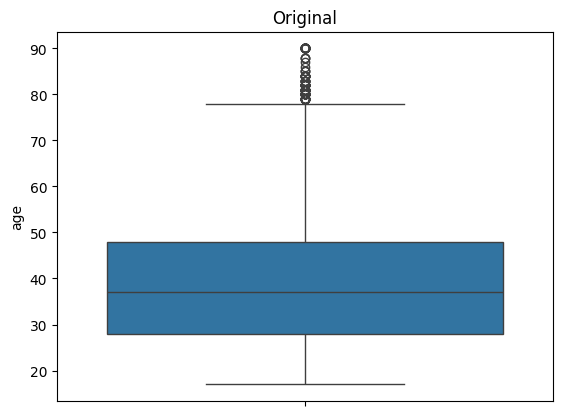

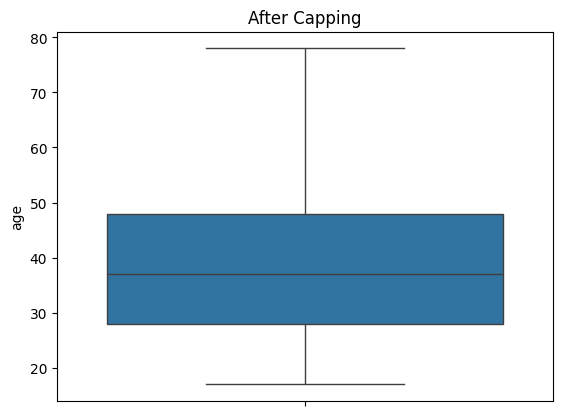

In [ ]:
# age value sets
sns.boxplot(y=df["age"])
plt.title("Original")
plt.show()

sns.boxplot(y=capped_df["age"])
plt.title("After Capping")
plt.show()

In [ ]:
# z-score for edu.num
from scipy.stats import zscore

z = zscore(df["education.num"])

df[abs(z) > 3]


# capping
mean = df["education.num"].mean()
std = df["education.num"].std()

lower_limit = mean - 3 * std
upper_limit = mean + 3 * std

education_capped = df.copy()

education_capped["education.num"] = education_capped[
    "education.num"
].clip(lower_limit, upper_limit)

In [ ]:
# IQR on capiatl.gain
Q1 = df["capital.gain"].quantile(0.25)
Q3 = df["capital.gain"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df[
(df["capital.gain"] < lower_limit) |
(df["capital.gain"] > upper_limit)
]

capital_gain_capped = df.copy()

capital_gain_capped["capital.gain"] = capital_gain_capped[
    "capital.gain"
].clip(lower_limit, upper_limit)

In [ ]:
# same for captial .loss
Q1 = df["capital.loss"].quantile(0.25)
Q3 = df["capital.loss"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df[
(df["capital.loss"] < lower_limit) |
(df["capital.loss"] > upper_limit)
]

capital_loss_capped = df.copy()

capital_loss_capped["capital.loss"] = capital_loss_capped[
    "capital.loss"
].clip(lower_limit, upper_limit)

In [ ]:
# z-score for hours per week
from scipy.stats import zscore

z = zscore(df["hours.per.week"])

df[abs(z) > 3]

mean = df["hours.per.week"].mean()
std = df["hours.per.week"].std()

lower_limit = mean - 3 * std
upper_limit = mean + 3 * std

hours_capped = df.copy()

hours_capped["hours.per.week"] = hours_capped[
    "hours.per.week"
].clip(lower_limit, upper_limit)

In [ ]:
# transformation

df["capital.gain"] = np.log1p(df["capital.gain"])
df["capital.loss"] = np.log1p(df["capital.loss"])
df[["capital.gain", "capital.loss"]].skew()

,0
capital.gain,3.094667
capital.loss,4.305701


In [ ]:
df[num_cols].skew()

,0
age,0.557663
fnlwgt,1.447703
education.num,-0.309500
capital.gain,3.094667
capital.loss,4.305701
hours.per.week,0.228759


In [ ]:
df["education"].unique()

array(['HS-grad', 'Some-college', '7th-8th', '10th', 'Doctorate',
       'Prof-school', 'Bachelors', 'Masters', '11th', 'Assoc-acdm',
       'Assoc-voc', '1st-4th', '5th-6th', '12th', '9th', 'Preschool'],
      dtype=object)

In [ ]:
# label encoding on sex
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "workclass",
        "marital.status",
        "occupation",
        "relationship",
        "race",
        "native.country"
    ],
    drop_first=True,
    dtype=int
)

In [ ]:
# drop columns
df.drop(columns=['fnlwgt', 'education','sex'], inplace=True)

In [ ]:
df.head()

,age,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,9,0.0,8.379539,40,<=50K,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,82,9,0.0,8.379539,18,<=50K,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,66,10,0.0,8.379539,40,<=50K,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,54,4,0.0,8.268988,40,<=50K,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,41,10,0.0,8.268988,40,<=50K,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
X = df.drop("income", axis=1)
y = df["income"]

In [ ]:
num_cols = [
    "age",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[num_cols] = scaler.fit_transform(X[num_cols])

In [ ]:
X[num_cols].head()

,age,education.num,capital.gain,capital.loss,hours.per.week
0,3.770003,-0.420679,-0.299391,5.065241,-0.035664
1,3.183397,-0.420679,-0.299391,5.065241,-1.817516
2,2.010185,-0.031815,-0.299391,5.065241,-0.035664
3,1.130276,-2.364998,-0.299391,4.995497,-0.035664
4,0.177041,-0.031815,-0.299391,4.995497,-0.035664


In [ ]:
print(df.shape)

(32537, 81)
